##  Visualisation - Bread Basket Analysis

## Objectives


- Analyze customer purchasing behaviour using the cleaned Bread Basket transaction dataset.
- Identify the most frequently purchased bakery products and understand product popularity.
- Examine purchasing trends based on time-related factors such as hour, day of the week, and month.
- Analyse customer transactions to understand multiple-product purchasing behaviour..
- Evaluate the EDA hypotheses through data analysis and visualizations.
- Generate insights to support inventory planning, product availability, and business decision-making.


## Input


Input data includes:

- Transaction ID
- Item name
- Transaction date and time
- Extracted features:
  - Hour of purchase
  - Day of the week
  - Month
  - Period of day
  - Weekday/Weekend classification

Dataset used:

clean_data/BreadBasket_clean.csv


## Output


- Summary statistics of customer transactions and product purchases.
- Identification of the most popular bakery products based on purchase frequency.
- Analysis of customer purchasing patterns across different time periods.
- Visualizations showing:
  - Top-selling products.
  - Hourly purchasing trends.
  - Daily and monthly purchasing patterns.
  - Weekday versus weekend behaviour.
- Product association analysis showing frequently purchased items together.
- Insights and recommendations to support inventory planning and business decisions.


## Hypotheses

*H1: Product Popularity Hypothesis*  
The cleaned transaction dataset will show that some bakery products are purchased more frequently than others.

*H2: Customer Purchasing Pattern Hypothesis*  
Customer purchasing behaviour changes depending on the time of day, day of the week, and month.

*H3: Multiple Product Purchase Hypothesis*  
Many customer transactions contain more than one bakery product, indicating opportunities for product bundling and cross-selling.

*H4: Business Insight Hypothesis*  
Analysis of customer purchasing patterns can provide insights to improve inventory planning, product availability, and business decision-making.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [57]:
# load the clean data set
df = pd.read_csv(r"../data_set/clean_data/bread_basket_cleaned.csv")

In [58]:
#inspect the data set to understand the stucture

df.head()
df.info()
df.describe(include="all")
df.shape
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      18887 non-null  int64 
 1   Item             18887 non-null  object
 2   date_time        18887 non-null  object
 3   period_day       18887 non-null  object
 4   weekday_weekend  18887 non-null  object
 5   date             18887 non-null  object
 6   time             18887 non-null  object
 7   hour             18887 non-null  int64 
 8   day_name         18887 non-null  object
 9   month            18887 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.4+ MB


Index(['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend',
       'date', 'time', 'hour', 'day_name', 'month'],
      dtype='object')

In [59]:
print("duplicates rows", df.duplicated().sum())

duplicates rows 0


In [60]:


#Get an overview of the data.Number of unique products and Number of purchase records.

print(f"Total records: {len(df)}")
print(f"Unique transactions: {df['Transaction'].nunique()}")
print(f"Unique products: {df['Item'].nunique()}")

Total records: 18887
Unique transactions: 9465
Unique products: 94


## Testing

### H1: Product Popularity Hypothesis

In [61]:
#find products which are purchased more frequently than others.
# how many times each product was purchased
product_counts = df["Item"].value_counts()

# top 10 products

print("Top 10 Most Purchased Products")

product_counts.head(10)

Top 10 Most Purchased Products


Item
Coffee           4528
Bread            3097
Tea              1350
Cake              983
Pastry            815
Sandwich          680
Medialuna         585
Hot chocolate     552
Cookies           515
Brownie           379
Name: count, dtype: int64

 The top 10 products purchased more frequently than other products.

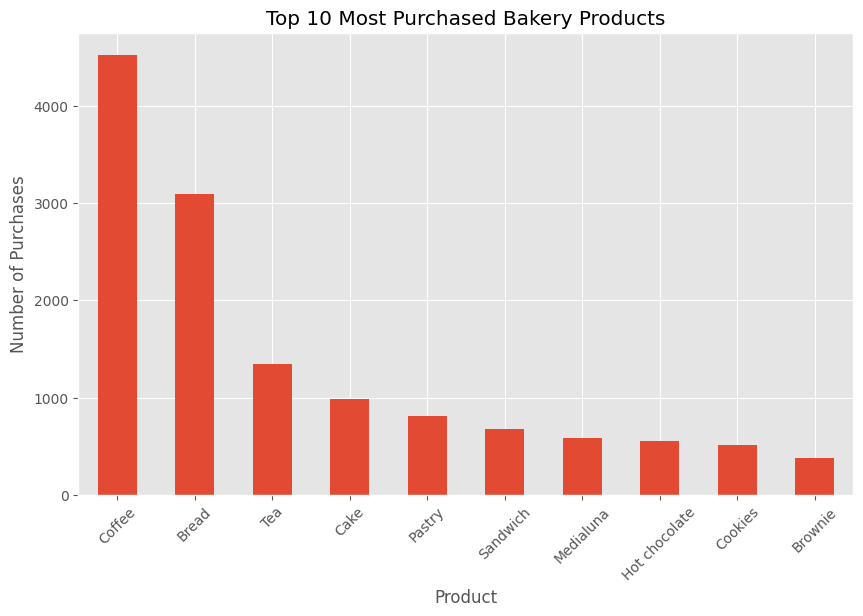

In [62]:
#creating a bar chart  
plt.figure(figsize=(10,6))

product_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Purchased Bakery Products")
plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)

plt.show()

##### Interpretation

The bar chart shows that a small number of bakery products account for the large majority of purchases, with a clear drop-off after the top two items.

 Coffee and Bread significantly outsell every other product on the list.

Tea and Cake comes second choice. *Pastry, **Sandwich, **Medialuna, **Hot Chocolate, **Cookies, and **Brownie*, which all sit below 1,000 purchases and are fairly close to one another in volume.

This pattern suggests that customer demand is concentrated around a few core items — especially Coffee and Bread — which should be prioritised for inventory management, stock availability, and possibly promotional bundling (e.g., pairing Coffee with lower-selling items to boost their sales).

### Hypothesis Evaluation

*H1: Supported*

The analysis supports the hypothesis that some bakery products are purchased more frequently than others. The purchase frequency distribution clearly shows that Coffee and Bread dominate customer purchases, while many other products are purchased less frequently.

### H2: Customer Purchasing Pattern Hypothesis

In [63]:

# Count purchases by hour
hourly_sales = df["hour"].value_counts().sort_index()

hourly_sales

hour
1        1
7       22
8      610
9     1820
10    2407
11    2837
12    2639
13    2440
14    2433
15    1941
16    1234
17     341
18      79
19      48
20      22
21       2
22       8
23       3
Name: count, dtype: int64

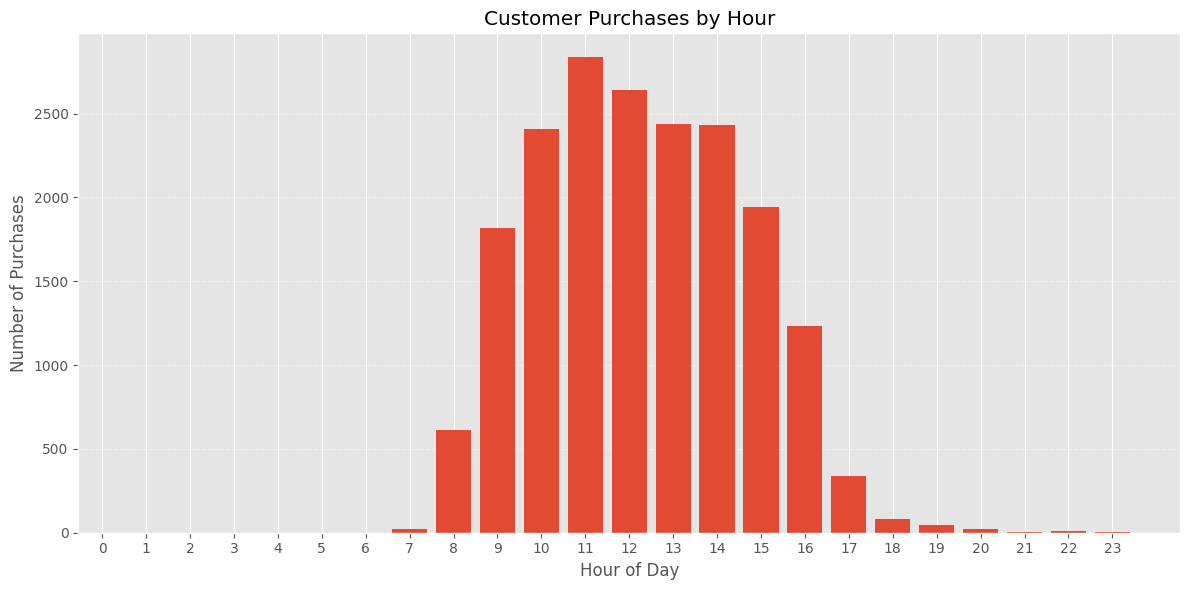

In [64]:
#create a bar chart to visualize the number of purchases by hour
plt.figure(figsize=(12,6))

plt.bar(hourly_sales.index, hourly_sales.values)

plt.title("Customer Purchases by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Purchases")
plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation

 Purchasing activity starts to increase in the morning, peaks between *11:00 AM and 12:00 PM*, and then gradually declines during the afternoon and evening.

This suggests that the bakery experiences its busiest period around lunchtime. Knowing these peak hours can help the business maintain adequate stock levels and schedule staff more effectively during high-demand periods.

In [36]:
 #Purchases by Day of the Week.Count Purchases by Day

# Define the correct order of weekdays
days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Count purchases by day and reorder
weekday_sales = (df["day_name"].value_counts().reindex(days))

# Display the results
weekday_sales

day_name
Monday       2144
Tuesday      2212
Wednesday    2150
Thursday     2458
Friday       2866
Saturday     4259
Sunday       2798
Name: count, dtype: int64

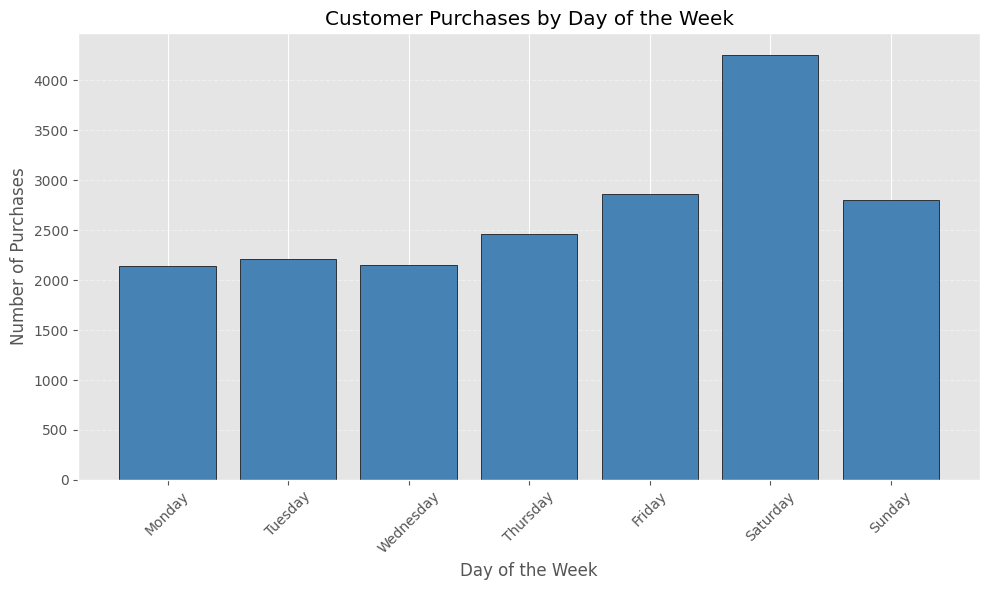

In [65]:
#create a bar chart to visualize the number of purchases by day of the week
plt.figure(figsize=(10,6))

plt.bar(weekday_sales.index,weekday_sales.values,color="steelblue",edgecolor="black")

plt.title("Customer Purchases by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation
The bar chart shows that customer purchasing activity varies across the days of the week. Purchases gradually increase from Monday to Friday, with *Saturday recording the highest number of purchases*. Purchasing activity decreases slightly on Sunday but remains higher than at the beginning of the week.

These findings suggest that customer demand is strongest during the weekend, particularly on Saturdays. This information can help the bakery plan inventory levels and staff scheduling to meet higher customer demand during peak days.

In [66]:
#Purchases by Month
#check data  more than one month

df["month"].value_counts()

month
November    4172
March       3658
February    3421
January     3128
December    3076
April       1086
October      346
Name: count, dtype: int64

customer purchasing behaviour across different months to identify seasonal trends.

In [67]:
#Arrange Months in Calendar Order

# Define the correct month order
months = ["January","February","March","April","October","November","December"]

# Count purchases and reorder
monthly_sales = (df["month"].value_counts().reindex(months))

monthly_sales

month
January     3128
February    3421
March       3658
April       1086
October      346
November    4172
December    3076
Name: count, dtype: int64

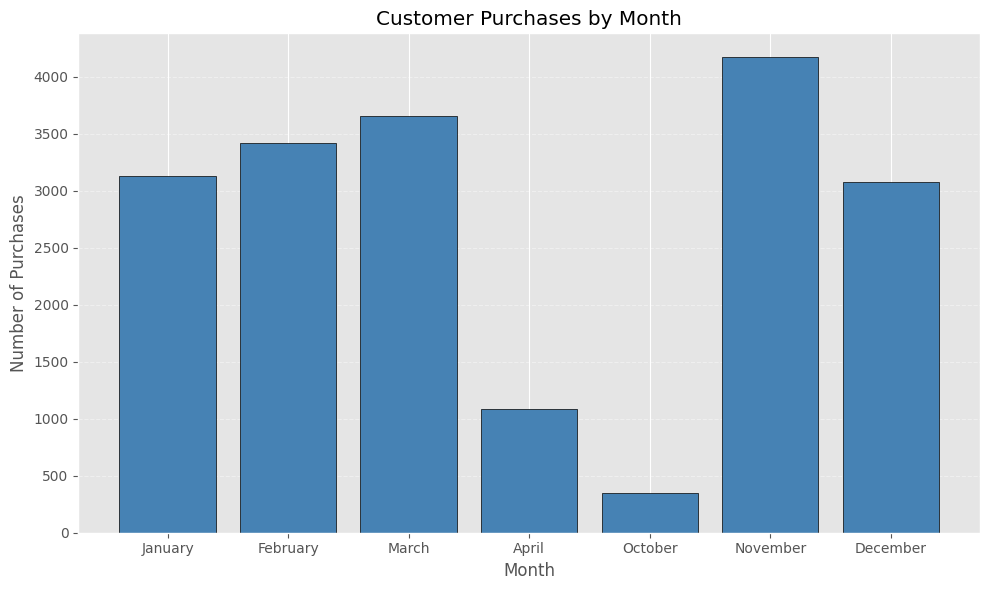

In [68]:
#Create the Chart

plt.figure(figsize=(10,6))

plt.bar(
    monthly_sales.index,
    monthly_sales.values,
    color="steelblue",
    edgecolor="black"
)

plt.title("Customer Purchases by Month")
plt.xlabel("Month")
plt.ylabel("Number of Purchases")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation

 November records the highest number of purchases, followed by March and February, while October has the fewest recorded purchases.

These differences indicate that purchasing activity is not evenly distributed across the dataset. However, the dataset may not contain the same amount of data for each month, so monthly comparisons should be interpreted with caution.

Overall, the analysis suggests that purchasing patterns vary over time, providing additional evidence for time-based customer behaviour.

In [69]:
#Weekday vs Weekend analysis

#Count Purchases
weekday_weekend_sales = (df["weekday_weekend"].value_counts())

weekday_weekend_sales

weekday_weekend
weekday    11830
weekend     7057
Name: count, dtype: int64

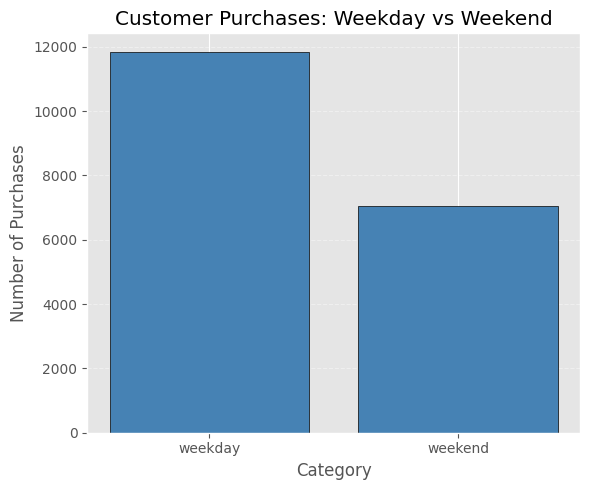

In [70]:
#Chart
plt.figure(figsize=(6,5))

plt.bar(
    weekday_weekend_sales.index,
    weekday_weekend_sales.values,
    color="steelblue",
    edgecolor="black"
)

plt.title("Customer Purchases: Weekday vs Weekend")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation

The number of weekday purchases is noticeably higher, indicating that most customer transactions take place during the working week.

These insights can help the bakery plan inventory levels and staffing according to expected demand

In [71]:
#Purchases by Period of Day.count purchases.

period_sales = (df["period_day"].value_counts())

period_sales

period_day
afternoon    10687
morning       7697
evening        490
night           13
Name: count, dtype: int64

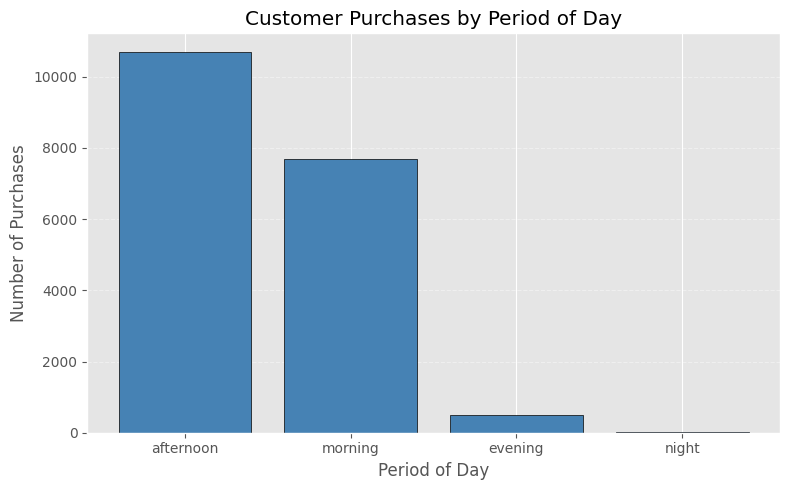

In [72]:
#Chart by period of Day

plt.figure(figsize=(8,5))

plt.bar(
    period_sales.index,
    period_sales.values,
    color="steelblue",
    edgecolor="black"
)

plt.title("Customer Purchases by Period of Day")
plt.xlabel("Period of Day")
plt.ylabel("Number of Purchases")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation

The bar chart shows that customer purchases are highest during the afternoon, followed by the morning. Purchasing activity is much lower during the evening, with almost no purchases recorded at night.


### Hypothesis Evaluation

*H2: Supported*

The analysis supports the hypothesis that customer purchasing behaviour changes depending on the time of day, day of the week, and month. The visualizations show clear differences in purchasing activity across different time periods.



### H3:Multiple Product Purchase Hypothesis


In [73]:
# Count the number of items in each transaction
transaction_size = df.groupby("Transaction")["Item"].count()

# Display the first few results
transaction_size.head()

Transaction
1    1
2    1
3    3
4    1
5    3
Name: Item, dtype: int64

In [74]:
#Summary Statistics
transaction_size.describe()

count    9465.000000
mean        1.995457
std         1.129543
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: Item, dtype: float64

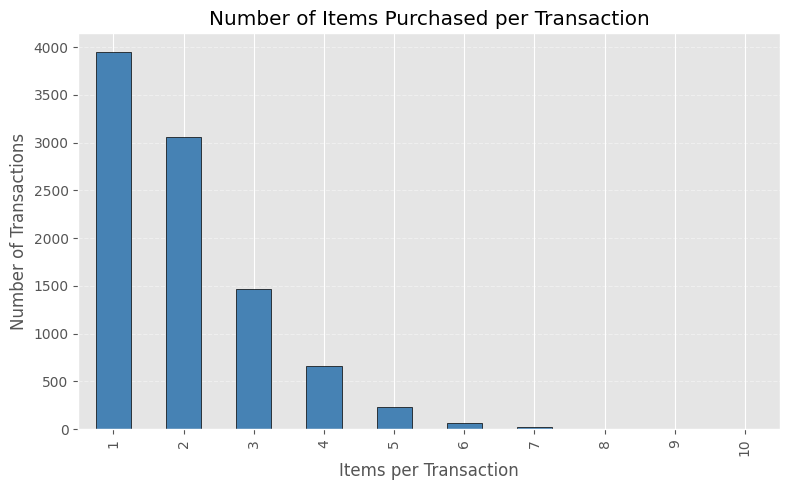

In [75]:
#Chart number of items purchased per transaction

plt.figure(figsize=(8,5))

transaction_size.value_counts().sort_index().plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Number of Items Purchased per Transaction")
plt.xlabel("Items per Transaction")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [76]:
#Transactions
df.groupby("Transaction")["Item"].apply(list).head(10)

Transaction
1                              [Bread]
2                       [Scandinavian]
3        [Hot chocolate, Jam, Cookies]
4                             [Muffin]
5              [Coffee, Pastry, Bread]
6          [Medialuna, Pastry, Muffin]
7     [Medialuna, Pastry, Coffee, Tea]
8                      [Pastry, Bread]
9                      [Bread, Muffin]
10           [Scandinavian, Medialuna]
Name: Item, dtype: object

##### Interpretation

Most customers buy one or two items per transaction. This suggests opportunities for product bundling and cross-selling.

### Hypothesis Evaluation

*H3: Supported*

The analysis shows that many transactions contain more than one product

### H4: Business Insight Hypothesis


 We use the previous analyses results to identify practical insights that can help improve bakery operations and business decision-making.


### Business Insights

Based on the analysis, the following business insights were identified:

- Coffee and Bread are the most popular products and should always be well stocked to meet customer demand.

- Customer purchases are highest around midday and during the afternoon, making these the busiest periods of the day.

- Saturday records the highest number of purchases, suggesting that additional staff and stock may be required during weekends.

- Many customers purchase more than one product in a single transaction, creating opportunities for product bundles and promotional offers.

- Understanding customer purchasing patterns can help improve inventory planning, staffing, and product availability.

### Hypothesis Evaluation

*H4: Supported*

The analysis provides useful insights into customer purchasing behaviour. These findings can help improve inventory planning, product availability, staffing, and promotional strategies.

## Conclusion

This project explored customer purchasing behaviour using the Bread Basket dataset after completing the ETL process and data cleaning.

The analysis showed that Coffee and Bread were the most popular bakery products. Customer purchasing behaviour varied by the time of day, day of the week, and month, with the highest purchasing activity occurring around midday and on Saturdays. The transaction analysis also showed that many customers purchased more than one product in a single transaction, highlighting opportunities for product bundling and cross-selling.

Overall, the project demonstrated how exploratory data analysis can identify customer purchasing patterns and provide useful insights to support inventory planning, product availability, staffing, and business decision-making

---